# BuahSafe Preliminary Machine Learning Study
## Extremely Explanatory Notebook for Non-AI Readers

Notebook ini dibuat sebagai **bahan belajar dan penelitian pendahuluan** untuk proyek BuahSafe. Fokusnya bukan sekadar menjalankan kode, tetapi memahami **apa yang dilakukan model, mengapa data diolah dengan cara tertentu, bagaimana hasil dibaca, dan apa maknanya untuk keputusan bisnis quality control buah**.

Dataset yang digunakan adalah dataset sekunder reflektansi biji kopi sangrai yang diukur menggunakan sensor **AS7265x**. Dataset ini dipakai karena sensor yang digunakan sama dengan rencana sensor BuahSafe, sehingga bentuk datanya relevan untuk latihan pipeline. Namun, objek biologisnya berbeda, sehingga model yang dihasilkan **bukan model final untuk jambu kristal**.

**Sumber dataset:**

`https://purple-given-lark-169.mypinata.cloud/ipfs/bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai`

## Inti Besar Notebook Ini

Bayangkan BuahSafe sebagai alat bantu sortasi. Buah dimasukkan ke chamber, sensor membaca pola cahaya, lalu sistem memberi keputusan apakah buah cenderung **normal** atau **bermasalah**. Model machine learning adalah bagian yang belajar dari contoh data agar bisa mengenali pola yang tidak mudah dilihat oleh manusia.

Pada dataset kopi ini, kita tidak mendeteksi jambu rusak. Kita mempelajari cara kerja sistemnya terlebih dahulu: bagaimana sensor menghasilkan data, bagaimana data dibaca oleh komputer, bagaimana model dilatih, dan bagaimana hasilnya dievaluasi. Ketika dataset primer jambu kristal tersedia, pipeline ini dapat digunakan ulang dengan mengganti data dan targetnya.

# 1. Business Logic: Model Ini Sebenarnya Ngapain?

Dalam konteks BuahSafe, model machine learning berperan sebagai **mesin pengambil keputusan berbasis data spektral**. Sensor AS7265x membaca intensitas cahaya pada beberapa panjang gelombang, lalu model mencari pola dari data tersebut. Pola ini kemudian digunakan untuk mengklasifikasikan kondisi sampel.

Secara sederhana:

```text
Buah / sampel
↓
Sensor membaca pola spektral
↓
Data masuk ke model machine learning
↓
Model memprediksi kelas
↓
Hasil dipakai untuk keputusan quality control
```

Untuk bisnis mitra, logikanya seperti ini. Jika buah rusak lolos sortasi, maka pelanggan bisa menerima produk buruk, kepercayaan turun, dan potensi kerugian meningkat. Jika alat dapat membantu mendeteksi buah bermasalah lebih awal, proses sortasi menjadi lebih objektif, cepat, dan terdokumentasi.

Pada penelitian primer BuahSafe, target akhirnya adalah membedakan **jambu normal** dan **jambu dengan anomali internal**. Pada notebook ini targetnya masih mengikuti dataset kopi, tetapi prinsip kerja modelnya sama. Model belajar dari data berlabel, lalu memprediksi label pada data baru.

# 2. Kenapa Pakai Dataset Kopi?

Dataset kopi dipakai karena beberapa alasan praktis dan metodologis. Pertama, dataset ini sudah tersedia dan dapat langsung digunakan untuk latihan. Kedua, dataset ini menggunakan sensor **AS7265x**, yaitu sensor yang sama dengan rencana BuahSafe. Ketiga, dataset ini memiliki bentuk data yang mirip dengan data primer yang nanti akan dikumpulkan, yaitu beberapa kanal panjang gelombang sebagai fitur.

Namun, ada batas yang harus sangat jelas. Dataset kopi tidak bisa digunakan untuk membuktikan bahwa BuahSafe mampu mendeteksi kerusakan internal jambu kristal. Kopi dan jambu memiliki karakteristik biologis, kadar air, struktur jaringan, dan target klasifikasi yang berbeda. Karena itu, notebook ini disebut **penelitian pendahuluan** atau **model latihan**, bukan model final.

Dengan latihan ini, tim dapat memahami pipeline sebelum data primer tersedia. Ketika pengambilan data jambu dimulai, tim tidak lagi belajar dari nol, tetapi sudah menguasai cara membaca data, melatih model, membandingkan algoritma, mengevaluasi performa, dan menghindari kesalahan umum seperti data leakage.

# 3. Pustaka Python yang Digunakan

Sebelum masuk ke kode, bagian ini menjelaskan fungsi library agar pembaca non-AI tidak hanya melihat nama paket tanpa memahami perannya.

| Library / Modul | Fungsi dalam Notebook |
|---|---|
| `pathlib.Path` | Mengelola lokasi file agar notebook bisa berjalan di Colab atau komputer lokal |
| `urllib.request.urlretrieve` | Mengunduh dataset dari URL IPFS |
| `hashlib` | Menghitung identitas digital file agar dataset yang dianalisis bisa ditelusuri |
| `json` | Menyimpan metadata eksperimen, seperti URL dataset dan daftar kanal |
| `zipfile` | Mengemas hasil eksperimen menjadi satu file ZIP |
| `warnings` | Mengurangi warning non-kritis agar output lebih mudah dibaca |
| `numpy` | Operasi numerik dan perhitungan array |
| `pandas` | Membaca CSV, mengelola tabel, dan melakukan audit data |
| `matplotlib` | Membuat grafik distribusi, spektrum, PCA, dan hasil regresi |
| `joblib` | Menyimpan model terlatih |
| `scikit-learn` | Menyediakan model machine learning, preprocessing, validasi, tuning, dan metrik evaluasi |

Bagian paling penting adalah `scikit-learn`. Pustaka ini dipakai karena sudah sangat umum untuk eksperimen machine learning berbasis tabel, termasuk dataset spektral seperti AS7265x. Model seperti Logistic Regression, SVM, dan Random Forest tersedia langsung, sehingga kita bisa fokus memahami pipeline dan interpretasi hasil.

In [1]:
# ============================================================
# OPSIONAL: INSTALASI LIBRARY
# ============================================================

# Di Google Colab, library ini biasanya sudah tersedia.
# Jalankan baris berikut hanya jika muncul error "ModuleNotFoundError".
# Tanda # berarti baris ini masih komentar dan tidak dieksekusi.

# %pip install -q numpy pandas matplotlib scikit-learn joblib

In [2]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Library standar Python untuk file, URL, metadata, dan arsip.
from pathlib import Path
from urllib.request import Request, urlopen, urlretrieve
import hashlib
import json
import warnings
import zipfile

# Library utama untuk data, angka, dan grafik.
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility dari scikit-learn.
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Fungsi untuk membagi data, validasi silang, dan tuning model.
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# Model baseline, yaitu model pembanding paling sederhana.
from sklearn.dummy import DummyClassifier, DummyRegressor

# Model klasifikasi dan regresi yang akan dibandingkan.
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Feature selection, PCA, dan interpretasi fitur.
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

# Metrik evaluasi.
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

# Warning non-kritis disembunyikan agar notebook lebih mudah dibaca.
warnings.filterwarnings("ignore")

# Pengaturan tampilan tabel pandas.
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)

print("Library berhasil diimpor. Notebook siap dijalankan.")

Library berhasil diimpor. Notebook siap dijalankan.


# 4. Konfigurasi Eksperimen

Konfigurasi ditempatkan di awal agar eksperimen mudah diulang dan diubah. Ini penting dalam penelitian karena hasil yang baik harus dapat direproduksi.

`RANDOM_STATE = 42` digunakan untuk mengunci proses acak. Misalnya, saat data dibagi menjadi data latih dan data uji, komputer sebenarnya melakukan pemilihan acak. Dengan random state yang sama, pembagian tersebut dapat diulang dengan hasil yang sama.

`TEST_SIZE = 0.20` berarti 20% data disisihkan sebagai data uji. Proporsi ini umum digunakan untuk dataset kecil-menengah karena masih menyisakan cukup banyak data untuk pelatihan, tetapi tetap menyediakan data yang belum dilihat model untuk evaluasi akhir.

`CV_FOLDS = 5` berarti cross-validation menggunakan lima pembagian. Ini membantu menilai apakah performa model stabil, bukan hanya kebetulan bagus pada satu pembagian data.

In [3]:
# ============================================================
# KONFIGURASI EKSPERIMEN
# ============================================================

# Mengunci proses acak agar hasil dapat direproduksi.
RANDOM_STATE = 42

# 20% data digunakan sebagai data uji akhir.
TEST_SIZE = 0.20

# Cross-validation menggunakan 5 fold.
CV_FOLDS = 5

# Sakelar eksperimen. Ubah menjadi False jika ingin runtime lebih cepat.
RUN_HYPERPARAMETER_TUNING = True
RUN_FEATURE_SELECTION_BENCHMARK = True
RUN_REGRESSION = True

print("Konfigurasi eksperimen:")
print(f"- RANDOM_STATE: {RANDOM_STATE}")
print(f"- TEST_SIZE: {TEST_SIZE}")
print(f"- CV_FOLDS: {CV_FOLDS}")

Konfigurasi eksperimen:
- RANDOM_STATE: 42
- TEST_SIZE: 0.2
- CV_FOLDS: 5


# 5. Mengunduh dan Membaca Dataset

Blok berikut bertugas mengambil dataset dari URL IPFS. Jika file sudah tersedia di folder kerja, notebook tidak perlu mengunduh ulang. Jika file belum tersedia, notebook mencoba mengunduhnya dari URL. Jika unduhan gagal di Colab, notebook akan meminta pengguna mengunggah file CSV secara manual.

Setelah file diperoleh, notebook menghitung **SHA-256**. SHA-256 adalah semacam sidik jari file. Jika isi file berubah sedikit saja, nilai SHA-256 ikut berubah. Ini berguna untuk dokumentasi penelitian, karena kita bisa mengetahui dataset mana yang sebenarnya dipakai saat eksperimen.

Setelah itu, `pd.read_csv()` membaca file CSV menjadi `DataFrame`. DataFrame adalah bentuk tabel pada pandas, mirip worksheet Excel, tetapi dapat diproses dengan kode.

In [4]:
# ============================================================
# MENGUNDUH DAN MEMBACA DATASET
# ============================================================

DATA_URL = (
    "https://purple-given-lark-169.mypinata.cloud/ipfs/"
    "bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai"
)

DATASET_NAME = (
    "Reflectance intensity dataset of roast coffee beans "
    "measured with AS7265X sensor.csv"
)

# Menentukan folder penyimpanan.
# Di Google Colab biasanya ada folder /content.
# Di komputer lokal, notebook menggunakan folder kerja saat ini.
if Path("/content").exists():
    data_directory = Path("/content")
else:
    data_directory = Path.cwd()

data_path = data_directory / DATASET_NAME

# Normalisasi nama dataset jika diunduh langsung dari link IPFS Pinata
# (misalnya bernama bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai atau variasi huruf/spasi)
if not data_path.exists():
    possible_names = [
        "bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai",
        "bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai.csv",
    ]
    for p_name in possible_names:
        cand = data_directory / p_name
        if cand.exists():
            print(f"Menemukan file dengan nama alternatif ('{p_name}'). Menormalisasi ke '{DATASET_NAME}'...")
            cand.rename(data_path)
            break
    if not data_path.exists():
        for f in data_directory.iterdir():
            if f.is_file() and ("bafkreieqtfnas62ufy5j5mevga7clt4fmokbnrovbtodv6zsbt7gurnfai" in f.name.lower() or (
                "reflectance" in f.name.lower() and "as7265" in f.name.lower() and f.name != DATASET_NAME
            )):
                print(f"Menormalisasi nama dataset dari '{f.name}' ke '{DATASET_NAME}'...")
                f.rename(data_path)
                break

# Jika file belum ada, unduh dari URL dengan User-Agent agar tidak trigger 403 Forbidden.
if not data_path.exists():
    print("Dataset belum tersedia secara lokal. Mengunduh dari IPFS Pinata...")

    try:
        req = Request(
            DATA_URL,
            headers={
                "User-Agent": (
                    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/122.0.0.0 Safari/537.36"
                ),
                "Accept": "*/*",
            },
        )
        with urlopen(req) as response, open(data_path, "wb") as out_file:
            out_file.write(response.read())
        print("Dataset berhasil diunduh tanpa trigger 403 Forbidden.")

    except Exception as download_error:
        # Fallback khusus Google Colab: pengguna dapat unggah file manual.
        try:
            from google.colab import files

            print("Unduhan otomatis gagal.")
            print("Silakan unggah file CSV dataset secara manual.")
            uploaded = files.upload()

            if uploaded:
                uploaded_name = next(iter(uploaded))
                data_path = Path("/content") / uploaded_name
            else:
                raise FileNotFoundError("Tidak ada file yang diunggah.")

        except ImportError:
            raise RuntimeError(
                "Dataset gagal diunduh dan notebook tidak berjalan di Google Colab. "
                "Letakkan CSV di folder kerja notebook atau periksa koneksi internet."
            ) from download_error
else:
    print("Dataset lokal ditemukan. Unduhan ulang tidak diperlukan.")

# Menghitung SHA-256 sebagai identitas digital dataset.
sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()

# Membaca CSV menjadi DataFrame.
df = pd.read_csv(data_path)

print(f"Lokasi dataset : {data_path}")
print(f"Ukuran file     : {data_path.stat().st_size:,} byte")
print(f"SHA-256         : {sha256}")
print(f"Ukuran tabel    : {df.shape[0]} baris × {df.shape[1]} kolom")

# Menampilkan lima baris pertama untuk inspeksi awal.
display(df.head())

Dataset lokal ditemukan. Unduhan ulang tidak diperlukan.
Lokasi dataset : f:\My Files\Projects\buahsafe\Reflectance intensity dataset of roast coffee beans measured with AS7265X sensor.csv
Ukuran file     : 48,026 byte
SHA-256         : 90995a097b542e3a9eb095303e25cf85639416c5d50cdc3afb320cfe6a45a502
Ukuran tabel    : 398 baris × 21 kolom


,No,Label,Agtron value,410 nm,435 nm,460 nm,485 nm,510 nm,535 nm,560 nm,585 nm,610 nm,645 nm,680 nm,705 nm,730 nm,760 nm,810 nm,860 nm,900 nm,940 nm
0,1,AF,121.2,1150.81,127.71,31.49,33.27,13.75,8.72,93.74,105.49,606.32,62.07,210.45,44.01,6.27,9.46,72.40,216.83,66.88,25.65
1,2,AF,122.6,1090.82,118.25,27.33,31.81,13.02,8.27,90.02,104.91,584.95,63.45,195.44,43.54,6.27,9.46,72.11,210.72,65.45,25.37
2,3,AF,122.4,1163.25,128.03,32.08,31.52,13.75,8.95,92.39,98.98,610.00,56.80,203.12,44.13,6.27,9.46,73.26,215.40,66.34,24.80
3,4,AF,121.0,1122.33,125.82,32.08,31.52,13.02,8.72,87.79,103.89,538.17,62.44,198.93,40.58,6.27,9.46,69.52,205.69,65.81,24.80
4,5,AF,113.4,1142.51,128.97,30.30,33.27,13.75,8.72,101.32,119.81,577.95,69.97,194.74,44.01,6.27,9.46,68.95,204.97,68.48,25.65


# 6. Audit Dataset: Mengecek Data Sebelum Dipakai Model

Sebelum melatih model, kita perlu memastikan dataset terbaca dengan benar. Ini seperti mengecek bahan baku sebelum produksi. Jika bahan baku salah, hasil akhirnya juga akan salah.

Audit data menjawab beberapa pertanyaan:

1. Apakah semua kolom memiliki tipe data yang benar?
2. Apakah ada nilai kosong?
3. Apakah ada baris duplikat?
4. Berapa banyak kelas target?
5. Apakah jumlah data pada setiap kelas seimbang?
6. Bagaimana sebaran `Agtron value`?

Dalam konteks bisnis, audit data penting karena keputusan sortasi akan sangat bergantung pada kualitas data. Jika data latih buruk, model bisa belajar pola yang salah, lalu menghasilkan keputusan yang menyesatkan.

In [5]:
# ============================================================
# AUDIT DATASET
# ============================================================

# Tabel audit menunjukkan tipe data, jumlah nilai kosong, dan jumlah nilai unik.
audit_table = pd.DataFrame({
    "Tipe data": df.dtypes.astype(str),
    "Jumlah kosong": df.isna().sum(),
    "Jumlah unik": df.nunique(),
})

display(audit_table)

# Mengecek duplikasi baris.
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

# Distribusi target klasifikasi.
print("\nDistribusi kelas pada kolom Label:")
display(df["Label"].value_counts().rename("Jumlah").to_frame())

# Statistik target regresi.
print("\nStatistik deskriptif Agtron value:")
display(df["Agtron value"].describe().to_frame().T)

,Tipe data,Jumlah kosong,Jumlah unik
No,int64,0,398
Label,str,0,4
Agtron value,float64,0,282
410 nm,float64,0,329
435 nm,float64,0,109
460 nm,float64,0,51
485 nm,float64,0,46
510 nm,float64,0,30
535 nm,float64,0,20
560 nm,float64,0,152


Jumlah baris duplikat: 0

Distribusi kelas pada kolom Label:


,Jumlah
Label,
RD,104
AF,102
AG,97
RT,95



Statistik deskriptif Agtron value:


,count,mean,std,min,25%,50%,75%,max
Agtron value,398.0,52.3,37.8233,5.0,19.325,44.8,72.8,131.5


# 7. Menentukan Fitur dan Target

Dalam machine learning, kita perlu memisahkan **fitur** dan **target**.

**Fitur** adalah informasi yang diberikan kepada model. Pada kasus ini, fitur adalah intensitas reflektansi pada 18 kanal panjang gelombang AS7265x, misalnya 410 nm, 435 nm, 460 nm, dan seterusnya. Fitur ini menjadi “bahan bacaan” model.

**Target** adalah jawaban yang ingin dipelajari model. Pada klasifikasi, targetnya adalah `Label`. Pada regresi, targetnya adalah `Agtron value`.

Kolom `No` tidak digunakan karena hanya nomor observasi. Kolom seperti ini tidak memiliki makna spektral. Jika dimasukkan ke model, model bisa belajar pola palsu dari urutan data, bukan dari sensor.

`Agtron value` juga tidak dimasukkan sebagai fitur klasifikasi. Alasannya adalah kita ingin mensimulasikan kondisi BuahSafe yang hanya menggunakan data sensor. Jika target atau variabel laboratorium dimasukkan sebagai fitur, evaluasi bisa terlihat terlalu bagus tetapi tidak realistis untuk alat nyata.

In [6]:
# ============================================================
# MENENTUKAN FITUR DAN TARGET
# ============================================================

# Semua kolom yang berakhiran "nm" dianggap sebagai kanal spektral.
# Cara otomatis ini membuat kode lebih fleksibel jika urutan kolom berubah.
wavelength_columns = [
    column
    for column in df.columns
    if column.strip().endswith("nm")
]

# X adalah matriks fitur yang akan dibaca model.
X = df[wavelength_columns].copy()

# y_class adalah target klasifikasi.
y_class = df["Label"].copy()

# y_reg adalah target regresi.
y_reg = df["Agtron value"].copy()

print(f"Jumlah kanal spektral: {len(wavelength_columns)}")
print("Daftar kanal spektral:")
print(wavelength_columns)

print("\nBentuk X:", X.shape)
print("Bentuk y_class:", y_class.shape)
print("Bentuk y_reg:", y_reg.shape)

Jumlah kanal spektral: 18
Daftar kanal spektral:
['410 nm', '435 nm', '460 nm', '485 nm', '510 nm', '535 nm', '560 nm', '585 nm', '610 nm', '645 nm', '680 nm', '705 nm', '730 nm', '760 nm', '810 nm', '860 nm', '900 nm', '940 nm']

Bentuk X: (398, 18)
Bentuk y_class: (398,)
Bentuk y_reg: (398,)


# 8. Exploratory Data Analysis: Memahami Pola Awal

Exploratory Data Analysis atau EDA adalah tahap melihat data sebelum model dilatih. Tujuannya bukan langsung mengambil kesimpulan final, tetapi memahami karakter umum dataset.

Kita akan melihat empat hal:

1. distribusi kelas;
2. profil spektral rata-rata tiap kelas;
3. distribusi `Agtron value`;
4. korelasi antar kanal.

Jika spektrum rata-rata antar kelas terlihat berbeda, itu indikasi awal bahwa data sensor mengandung informasi yang mungkin bisa dipelajari model. Namun, perbedaan visual belum cukup. Model tetap harus diuji dengan data yang belum pernah dilihat.

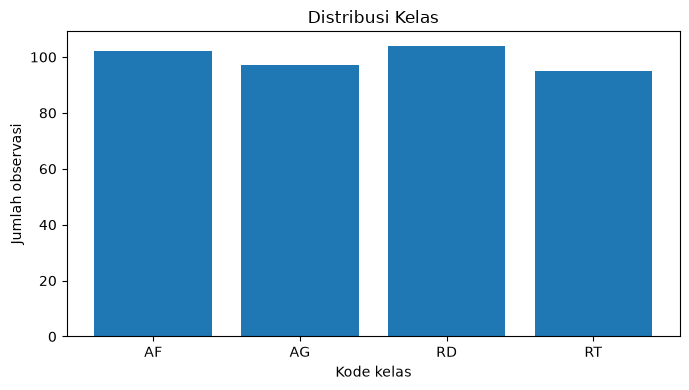

In [7]:
# ============================================================
# DISTRIBUSI KELAS
# ============================================================

# Menghitung jumlah observasi pada setiap kelas.
class_counts = y_class.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Kode kelas")
plt.ylabel("Jumlah observasi")
plt.title("Distribusi Kelas")
plt.tight_layout()
plt.show()

## Cara Membaca Grafik Distribusi Kelas

Grafik ini menunjukkan jumlah data pada setiap kelas. Jika satu kelas jauh lebih banyak daripada kelas lain, dataset disebut tidak seimbang. Dataset tidak seimbang dapat membuat accuracy menipu.

Misalnya, jika 90% data adalah kelas A, model yang selalu menjawab A bisa memiliki accuracy 90%, tetapi sebenarnya tidak pintar. Karena itu, kita juga menggunakan precision, recall, dan F1-score, bukan hanya accuracy.

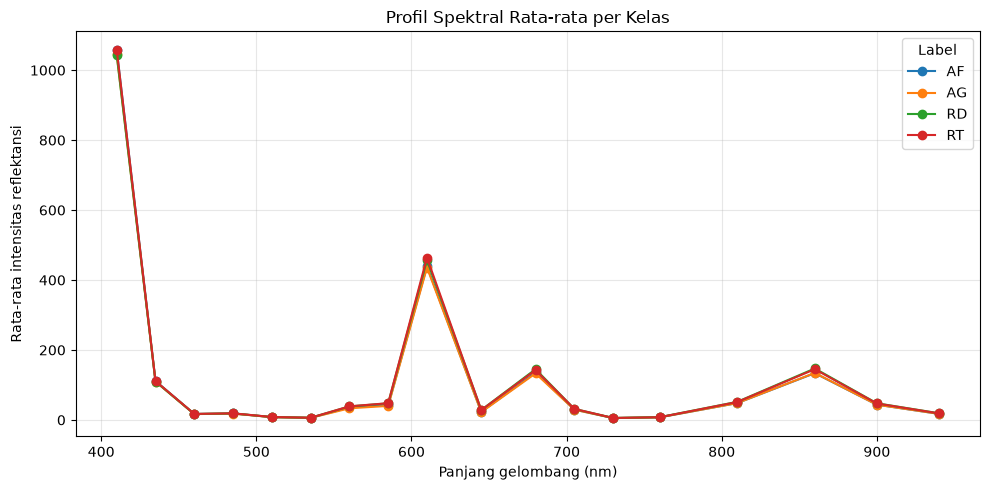

In [8]:
# ============================================================
# PROFIL SPEKTRAL RATA-RATA PER KELAS
# ============================================================

# Mengubah nama kolom seperti "410 nm" menjadi angka 410.
wavelength_values = [
    int(column.replace(" nm", ""))
    for column in wavelength_columns
]

plt.figure(figsize=(10, 5))

# Untuk setiap kelas, hitung rata-rata intensitas pada setiap kanal.
for label, group in df.groupby("Label"):
    mean_spectrum = group[wavelength_columns].mean().to_numpy()

    plt.plot(
        wavelength_values,
        mean_spectrum,
        marker="o",
        label=str(label),
    )

plt.xlabel("Panjang gelombang (nm)")
plt.ylabel("Rata-rata intensitas reflektansi")
plt.title("Profil Spektral Rata-rata per Kelas")
plt.legend(title="Label")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cara Membaca Grafik Spektral

Setiap garis menunjukkan pola rata-rata satu kelas. Jika garis antar kelas berbeda pada panjang gelombang tertentu, kanal tersebut mungkin membantu membedakan kelas.

Dalam BuahSafe, logikanya serupa. Buah normal dan buah dengan anomali internal diharapkan memiliki pola spektral berbeda karena kondisi internalnya berbeda. Perbedaan itu bisa berasal dari perubahan kadar air, struktur jaringan, pembusukan, rongga, atau perubahan komposisi kimia.

Namun, kita harus hati-hati. Grafik rata-rata hanya petunjuk awal. Model tetap perlu diuji karena pola rata-rata bisa menyembunyikan variasi antar sampel.

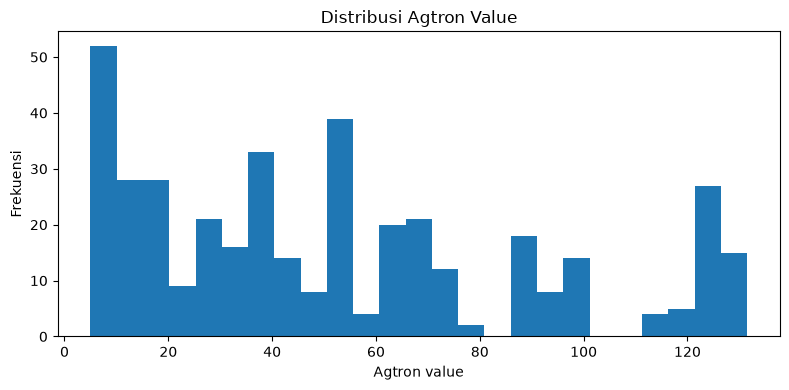

In [9]:
# ============================================================
# DISTRIBUSI TARGET REGRESI
# ============================================================

plt.figure(figsize=(8, 4))
plt.hist(y_reg, bins=25)
plt.xlabel("Agtron value")
plt.ylabel("Frekuensi")
plt.title("Distribusi Agtron Value")
plt.tight_layout()
plt.show()

## Kenapa Agtron Value Juga Dilihat?

`Agtron value` adalah target numerik pada dataset kopi. Dalam notebook ini, ia dipakai untuk latihan regresi. Ini membantu tim memahami bahwa supervised learning tidak hanya untuk klasifikasi, tetapi juga bisa untuk prediksi angka.

Dalam BuahSafe, klasifikasi lebih relevan untuk keputusan awal karena target bisnisnya adalah membedakan buah normal dan buah bermasalah. Namun, regresi berguna untuk memperluas pemahaman, misalnya jika suatu saat ingin memprediksi skor mutu, tingkat kematangan, atau indeks risiko.

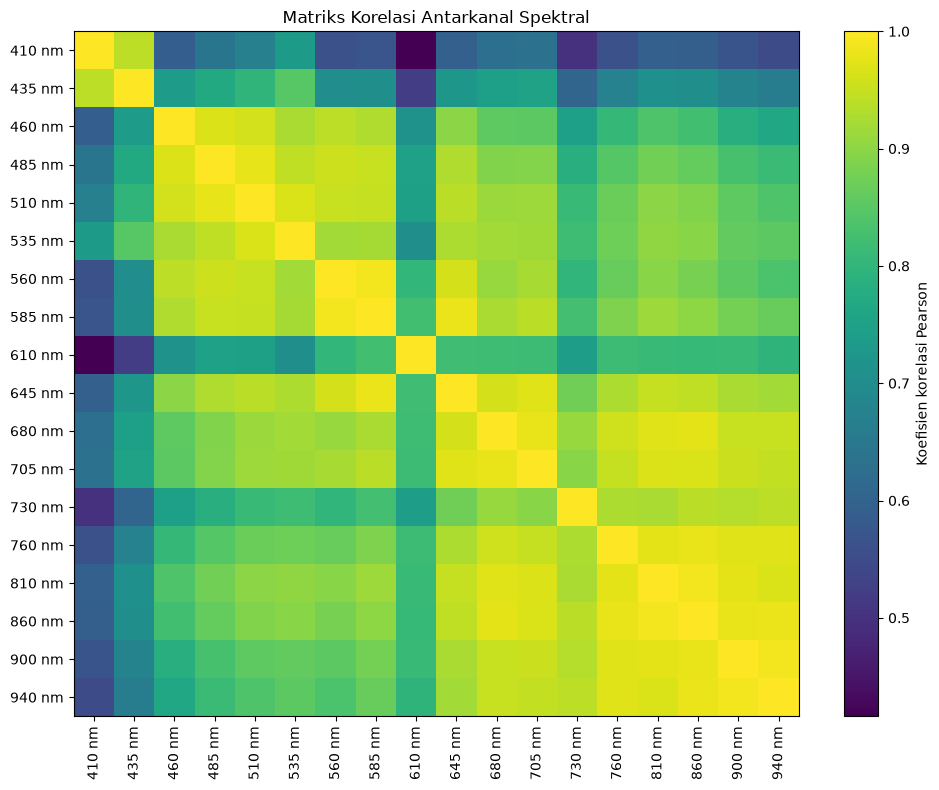

In [10]:
# ============================================================
# KORELASI ANTARKANAL
# ============================================================

# Korelasi mengukur hubungan linear antara dua kanal.
correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Koefisien korelasi Pearson")
plt.xticks(
    range(len(wavelength_columns)),
    wavelength_columns,
    rotation=90,
)
plt.yticks(
    range(len(wavelength_columns)),
    wavelength_columns,
)
plt.title("Matriks Korelasi Antarkanal Spektral")
plt.tight_layout()
plt.show()

## Cara Membaca Korelasi Antarkanal

Kanal yang berdekatan sering berkorelasi karena mengukur bagian spektrum yang berdekatan. Korelasi tinggi berarti dua kanal membawa informasi yang mirip.

Dalam bisnis alat, ini penting karena jika beberapa kanal sangat mirip, mungkin tidak semuanya dibutuhkan. Itulah dasar dari feature selection. Jika performa tetap baik dengan sedikit kanal, sistem bisa menjadi lebih sederhana, cepat, dan murah. Tetapi untuk BuahSafe v1, karena AS7265x memang menyediakan 18 kanal, kita tetap dapat membaca semuanya terlebih dahulu lalu memilih kanal yang paling informatif melalui analisis.

# 9. Membagi Dataset: Data Latih dan Data Uji

Model harus diuji pada data yang belum pernah dilihat. Jika model dilatih dan diuji pada data yang sama, hasilnya bisa terlihat sangat bagus, tetapi tidak mencerminkan kemampuan pada kasus baru.

Karena itu dataset dibagi menjadi:

- **data latih**, digunakan untuk mengajari model;
- **data uji**, digunakan untuk mengecek apakah model bisa bekerja pada data baru.

Notebook ini menggunakan proporsi **80% data latih dan 20% data uji**. Proporsi ini umum untuk dataset kecil-menengah karena masih memberi cukup data untuk pelatihan, tetapi tetap menyediakan data uji yang cukup untuk evaluasi.

`stratify=y_class` digunakan agar proporsi kelas pada data latih dan data uji tetap mirip. Ini penting agar data uji tidak kebetulan kehilangan salah satu kelas.

In [11]:
# ============================================================
# TRAIN-TEST SPLIT UNTUK KLASIFIKASI
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=TEST_SIZE,
    stratify=y_class,
    random_state=RANDOM_STATE,
)

print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)

# Membandingkan proporsi kelas sebelum dan sesudah split.
class_proportion_comparison = pd.DataFrame({
    "Seluruh data": y_class.value_counts(normalize=True).sort_index(),
    "Data latih": y_train.value_counts(normalize=True).sort_index(),
    "Data uji": y_test.value_counts(normalize=True).sort_index(),
})

display(class_proportion_comparison)

Ukuran data latih: (318, 18)
Ukuran data uji  : (80, 18)


,Seluruh data,Data latih,Data uji
Label,,,
AF,0.2563,0.2547,0.2625
AG,0.2437,0.2453,0.2375
RD,0.2613,0.2610,0.2625
RT,0.2387,0.2390,0.2375


## Catatan Penting: Data Leakage

Data leakage terjadi ketika informasi dari data uji tidak sengaja masuk ke proses pelatihan. Ini membuat evaluasi terlihat lebih bagus daripada kondisi nyata.

Dalam dataset primer BuahSafe, leakage bisa terjadi jika satu buah dipindai beberapa kali, lalu sebagian scan masuk data latih dan sebagian scan masuk data uji. Model bisa mengenali karakter buah yang sama, bukan benar-benar belajar membedakan buah normal dan rusak.

Karena itu, saat data primer tersedia, pembagian data sebaiknya berdasarkan `fruit_id`, bukan baris scan. Semua scan dari satu buah harus masuk kelompok yang sama.

# 10. Model Baseline dan Model Utama

Notebook ini membandingkan empat model klasifikasi.

## Dummy Classifier

Dummy Classifier adalah model pembanding paling sederhana. Model ini tidak membaca spektrum secara bermakna. Ia hanya menebak berdasarkan strategi sederhana, misalnya memilih kelas yang paling sering muncul.

Jika model canggih tidak mengalahkan Dummy Classifier, berarti model canggih tersebut belum benar-benar belajar pola yang berguna.

## Logistic Regression

Logistic Regression adalah model klasifikasi linear. Model ini cocok sebagai baseline ilmiah karena sederhana, cepat, dan mudah ditafsirkan. Dalam penelitian, model sederhana penting karena bisa menjadi pembanding sebelum memakai model yang lebih kompleks.

## Support Vector Machine

SVM berguna untuk data berdimensi cukup tinggi seperti data spektral. Dengan kernel RBF, SVM dapat menangani pola non-linear. Ini relevan karena hubungan antara spektrum dan kondisi sampel tidak selalu lurus sederhana.

## Random Forest

Random Forest adalah kumpulan banyak decision tree. Model ini kuat untuk pola non-linear dan interaksi antar fitur. Random Forest sering digunakan sebagai model praktis karena performanya stabil pada banyak dataset tabular.

## Kenapa tiga model ini?

Dalam proposal BuahSafe, LR, SVM, dan RF dipilih karena mewakili tiga pendekatan berbeda: linear, margin-based non-linear, dan ensemble tree-based. Dengan membandingkan ketiganya, kita tidak bergantung pada satu asumsi model saja.

In [12]:
# ============================================================
# DEFINISI MODEL KLASIFIKASI
# ============================================================

classification_models = {
    # Baseline: model yang sangat sederhana.
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    # Logistic Regression memerlukan scaling.
    # class_weight="balanced" membantu jika kelas tidak seimbang.
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    # SVM dengan kernel RBF untuk menangkap pola non-linear.
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),

    # Random Forest tidak memerlukan scaling karena berbasis tree.
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

# Cross-validation stratified menjaga proporsi kelas pada setiap fold.
classification_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print("Model klasifikasi dan skema cross-validation sudah siap.")

Model klasifikasi dan skema cross-validation sudah siap.


# 11. Kenapa Perlu Scaling dan Pipeline?

Beberapa model sensitif terhadap skala fitur. Misalnya, jika satu kanal memiliki nilai jauh lebih besar dari kanal lain, model seperti Logistic Regression dan SVM bisa terlalu memperhatikan kanal tersebut hanya karena skalanya besar, bukan karena informasinya lebih penting.

`StandardScaler` mengubah setiap fitur agar memiliki rata-rata sekitar 0 dan standar deviasi sekitar 1. Ini membuat model membaca semua kanal dengan skala yang lebih seimbang.

`Pipeline` digunakan agar preprocessing dan model menjadi satu alur. Ini penting untuk mencegah data leakage. Scaling harus dipelajari dari data latih saja, bukan dari seluruh dataset. Pipeline memastikan prosedur itu dilakukan dengan benar pada setiap fold cross-validation.

# 12. Cross-Validation dan Evaluasi Awal

Cross-validation digunakan agar evaluasi tidak hanya bergantung pada satu pembagian data. Pada 5-fold cross-validation, data dibagi menjadi lima bagian. Model dilatih pada empat bagian dan divalidasi pada satu bagian. Proses ini diulang lima kali.

Metrik yang digunakan:

- **Accuracy**: persentase prediksi benar secara keseluruhan.
- **Precision macro**: dari semua sampel yang diprediksi sebagai kelas tertentu, berapa yang benar, dirata-ratakan antar kelas.
- **Recall macro**: dari semua sampel yang sebenarnya termasuk kelas tertentu, berapa yang berhasil ditemukan, dirata-ratakan antar kelas.
- **F1 macro**: gabungan precision dan recall, dirata-ratakan antar kelas.

Dalam BuahSafe, **recall untuk kelas rusak** akan sangat penting karena buah rusak yang lolos sortasi dapat merugikan mitra. Namun, pada dataset latihan ini kita memakai macro average karena dataset memiliki beberapa kelas dan kita ingin memperlakukan semua kelas secara seimbang.

In [13]:
# ============================================================
# MELATIH DAN MEMBANDINGKAN MODEL KLASIFIKASI
# ============================================================

classification_results = []
fitted_classification_models = {}

for model_name, model in classification_models.items():

    # Cross-validation mengukur performa rata-rata pada beberapa pembagian data.
    cv_scores = cross_validate(
        estimator=model,
        X=X,
        y=y_class,
        cv=classification_cv,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
        },
        n_jobs=-1,
    )

    # clone membuat salinan model yang masih bersih.
    fitted_model = clone(model)

    # Model dilatih pada data latih.
    fitted_model.fit(X_train, y_train)

    # Model diuji pada data uji.
    test_predictions = fitted_model.predict(X_test)

    # Model disimpan untuk analisis berikutnya.
    fitted_classification_models[model_name] = fitted_model

    # Hasil metrik dirangkum ke tabel.
    classification_results.append({
        "Model": model_name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV F1 Macro": cv_scores["test_f1_macro"].mean(),
        "Test Accuracy": accuracy_score(y_test, test_predictions),
        "Test Precision Macro": precision_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0,
        ),
        "Test Recall Macro": recall_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0,
        ),
        "Test F1 Macro": f1_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0,
        ),
    })

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("Test F1 Macro", ascending=False)
    .reset_index(drop=True)
)

display(
    classification_results_df.style.format({
        column: "{:.4f}"
        for column in classification_results_df.columns
        if column != "Model"
    })
)

,Model,CV Accuracy,CV F1 Macro,Test Accuracy,Test Precision Macro,Test Recall Macro,Test F1 Macro
0,Random Forest,0.7261,0.7216,0.6750,0.6905,0.6817,0.6679
1,SVM,0.4724,0.4706,0.5000,0.5560,0.4962,0.4944
2,Logistic Regression,0.3999,0.3972,0.4500,0.4388,0.4486,0.4412
3,Dummy Baseline,0.2613,0.1036,0.2625,0.0656,0.2500,0.1040


## Cara Membaca Tabel Hasil Model

Tabel di atas menjawab pertanyaan: model mana yang paling baik pada dataset latihan ini?

Hal pertama yang perlu dicek adalah apakah model utama mengalahkan Dummy Baseline. Jika tidak, berarti model belum belajar pola yang berarti. Setelah itu, bandingkan F1 macro karena metrik ini lebih seimbang daripada accuracy.

Jika hasil CV dan test set relatif dekat, model cenderung stabil. Jika hasil CV tinggi tetapi test rendah, model mungkin terlalu cocok pada data latih atau pembagian data uji lebih sulit. Jika test sangat tinggi tetapi CV tidak stabil, hasil itu mungkin kebetulan dari satu pembagian data.

Dalam konteks bisnis BuahSafe, kita tidak hanya mencari model dengan angka tertinggi. Kita mencari model yang stabil, masuk akal, dapat dijelaskan, dan mampu mengurangi risiko buah rusak lolos sortasi.

Logistic Regression
              precision    recall  f1-score   support

          AF       0.58      0.67      0.62        21
          AG       0.43      0.47      0.45        19
          RD       0.38      0.29      0.32        21
          RT       0.37      0.37      0.37        19

    accuracy                           0.45        80
   macro avg       0.44      0.45      0.44        80
weighted avg       0.44      0.45      0.44        80



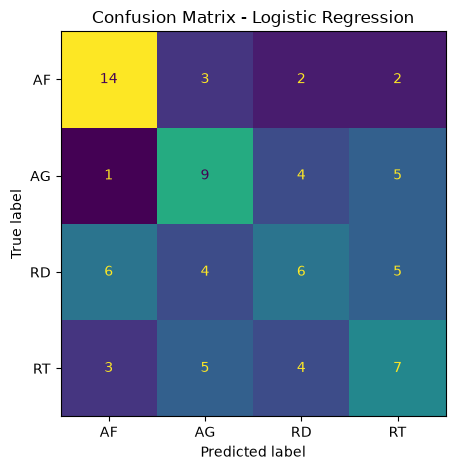

SVM
              precision    recall  f1-score   support

          AF       0.55      0.81      0.65        21
          AG       0.89      0.42      0.57        19
          RD       0.47      0.33      0.39        21
          RT       0.32      0.42      0.36        19

    accuracy                           0.50        80
   macro avg       0.56      0.50      0.49        80
weighted avg       0.55      0.50      0.50        80



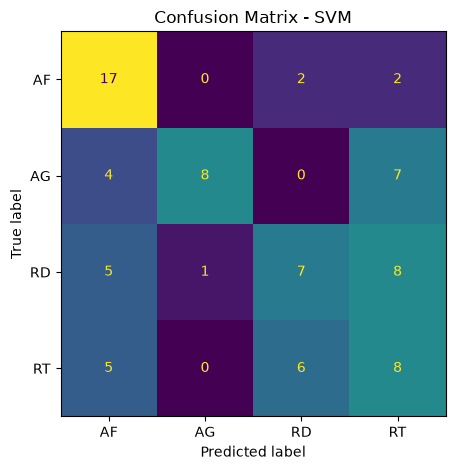

Random Forest
              precision    recall  f1-score   support

          AF       0.72      0.62      0.67        21
          AG       0.62      0.95      0.75        19
          RD       0.77      0.48      0.59        21
          RT       0.65      0.68      0.67        19

    accuracy                           0.68        80
   macro avg       0.69      0.68      0.67        80
weighted avg       0.69      0.68      0.67        80



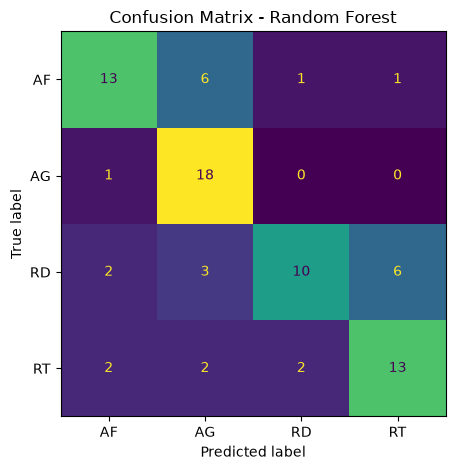

In [14]:
# ============================================================
# CLASSIFICATION REPORT DAN CONFUSION MATRIX
# ============================================================

for model_name in [
    "Logistic Regression",
    "SVM",
    "Random Forest",
]:
    model = fitted_classification_models[model_name]
    predictions = model.predict(X_test)

    print("=" * 80)
    print(model_name)

    # Classification report menunjukkan precision, recall, dan F1 per kelas.
    print(classification_report(
        y_test,
        predictions,
        zero_division=0,
    ))

    # Confusion matrix menunjukkan kelas mana yang tertukar.
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        colorbar=False,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

## Cara Membaca Confusion Matrix

Confusion matrix menunjukkan perbandingan antara label aktual dan label prediksi. Angka pada diagonal utama adalah prediksi yang benar. Angka di luar diagonal menunjukkan kesalahan.

Dalam konteks BuahSafe nanti, confusion matrix akan sangat penting karena jenis kesalahan tidak sama dampaknya.

- **False negative**: buah rusak diprediksi normal. Ini berbahaya karena buah rusak bisa lolos ke konsumen.
- **False positive**: buah normal diprediksi rusak. Ini juga merugikan karena buah bagus bisa ditolak, tetapi dampaknya sering lebih terkendali dibanding buah rusak lolos.

Karena itu, pada dataset primer BuahSafe nanti, recall untuk kelas rusak kemungkinan menjadi metrik utama yang perlu diperhatikan.

# 13. Hyperparameter Tuning

Model memiliki pengaturan yang disebut hyperparameter. Hyperparameter bukan dipelajari langsung dari data, tetapi ditentukan sebelum model dilatih.

Contohnya:

- `C` pada Logistic Regression dan SVM mengatur regularisasi;
- `gamma` pada SVM mengatur seberapa jauh pengaruh satu titik data;
- `n_estimators` pada Random Forest menentukan jumlah pohon;
- `max_depth` membatasi kedalaman pohon;
- `min_samples_leaf` mengatur jumlah minimal data pada daun pohon.

`GridSearchCV` mencoba beberapa kombinasi hyperparameter dan memilih kombinasi terbaik berdasarkan cross-validation. Data uji tetap tidak digunakan dalam proses pemilihan parameter. Ini penting agar evaluasi akhir tetap jujur.

In [15]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

tuned_models = {}
tuning_results = []

if RUN_HYPERPARAMETER_TUNING:

    tuning_configurations = {
        "Logistic Regression": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                )),
            ]),
            "parameters": {
                "model__C": [0.01, 0.1, 1, 10, 100],
            },
        },

        "SVM": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(
                    kernel="rbf",
                    class_weight="balanced",
                    probability=True,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "parameters": {
                "model__C": [0.1, 1, 10, 100],
                "model__gamma": ["scale", 0.01, 0.1, 1],
            },
        },

        "Random Forest": {
            "estimator": RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            "parameters": {
                "n_estimators": [150, 300],
                "max_depth": [None, 5, 10],
                "min_samples_leaf": [1, 2, 4],
            },
        },
    }

    for model_name, configuration in tuning_configurations.items():

        # GridSearchCV mencari kombinasi hyperparameter terbaik.
        search = GridSearchCV(
            estimator=configuration["estimator"],
            param_grid=configuration["parameters"],
            scoring="f1_macro",
            cv=classification_cv,
            n_jobs=-1,
            refit=True,
        )

        # Tuning dilakukan hanya pada data latih.
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        predictions = best_model.predict(X_test)

        tuned_models[model_name] = best_model

        tuning_results.append({
            "Model": model_name,
            "Best Parameters": search.best_params_,
            "Best CV F1 Macro": search.best_score_,
            "Test Accuracy": accuracy_score(y_test, predictions),
            "Test F1 Macro": f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
        })

    tuning_results_df = (
        pd.DataFrame(tuning_results)
        .sort_values("Test F1 Macro", ascending=False)
        .reset_index(drop=True)
    )

    display(tuning_results_df)

else:
    print("Hyperparameter tuning dilewati.")

,Model,Best Parameters,Best CV F1 Macro,Test Accuracy,Test F1 Macro
0,SVM,"{'model__C': 10, 'model__gamma': 1}",0.7217,0.750,0.7461
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",0.6981,0.675,0.6685
2,Logistic Regression,{'model__C': 1},0.3593,0.450,0.4412


## Cara Membaca Hasil Tuning

Tuning tidak selalu membuat model lebih baik pada data uji. Kadang tuning meningkatkan hasil cross-validation tetapi tidak meningkatkan hasil test set. Itu normal.

Dalam penelitian, tuning berguna karena membuat proses pemilihan parameter lebih sistematis. Namun, tuning yang terlalu agresif pada dataset kecil bisa menyebabkan model terlalu menyesuaikan diri dengan data latih. Karena itu, hasil tuning tetap harus dibaca bersama test set dan cross-validation.

Untuk BuahSafe, tuning akan dilakukan lagi pada dataset primer. Parameter terbaik pada dataset kopi tidak otomatis menjadi parameter terbaik untuk jambu kristal.

# 14. Feature Selection: Memilih Kanal yang Paling Informatif

AS7265x memiliki 18 kanal. Mengurangi 18 kanal menjadi beberapa kanal yang paling relevan disebut **feature selection**. Dalam konteks spektroskopi, ini juga disebut **wavelength selection** atau **spectral band selection**.

Kenapa feature selection penting?

Pertama, tidak semua kanal selalu membawa informasi penting. Kedua, beberapa kanal bisa redundan atau membawa noise. Ketiga, jika suatu saat sistem ingin dibuat lebih murah atau lebih cepat, mengetahui kanal penting dapat membantu desain alat.

Notebook menggunakan `SelectKBest(f_classif)`. Metode ini menghitung skor statistik ANOVA untuk melihat kanal mana yang paling berbeda antar kelas. Semakin tinggi skor, semakin besar potensi kanal tersebut untuk membantu klasifikasi.

Namun, kanal penting pada dataset kopi tidak otomatis penting pada jambu kristal. Analisis ini adalah latihan metodologi, bukan keputusan final sensor BuahSafe.

,Model,Jumlah kanal,CV F1 Macro,Simpangan baku
0,Logistic Regression,4,0.3229,0.0508
1,SVM,4,0.5476,0.0407
2,Random Forest,4,0.5189,0.0274
3,Logistic Regression,8,0.3302,0.0696
4,SVM,8,0.6076,0.0394
5,Random Forest,8,0.6399,0.0140
6,Logistic Regression,12,0.3810,0.0927
7,SVM,12,0.6618,0.0304
8,Random Forest,12,0.6630,0.0423
9,Logistic Regression,18,0.3972,0.0749


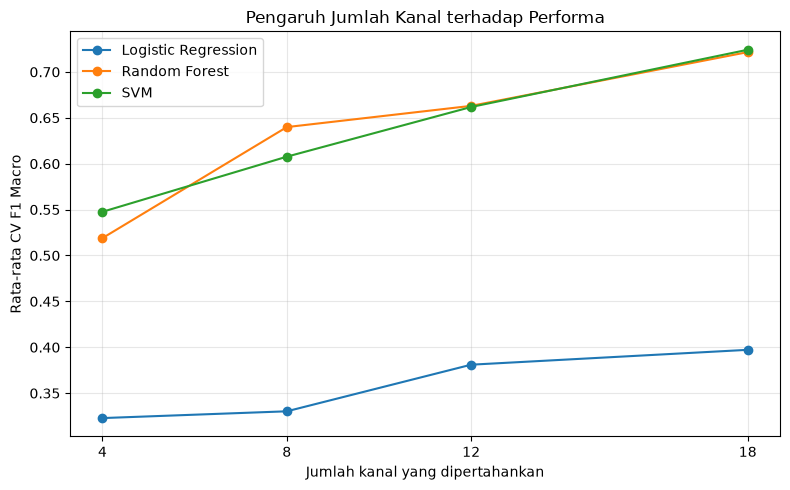

In [16]:
# ============================================================
# BENCHMARK JUMLAH KANAL
# ============================================================

feature_selection_results = []

if RUN_FEATURE_SELECTION_BENCHMARK:

    # Membandingkan performa ketika hanya memakai 4, 8, 12, dan 18 kanal.
    for number_of_features in [4, 8, 12, 18]:

        selection_models = {
            "Logistic Regression": Pipeline([
                ("selector", SelectKBest(
                    score_func=f_classif,
                    k=number_of_features,
                )),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                )),
            ]),

            "SVM": Pipeline([
                ("selector", SelectKBest(
                    score_func=f_classif,
                    k=number_of_features,
                )),
                ("scaler", StandardScaler()),
                ("model", SVC(
                    kernel="rbf",
                    C=10,
                    gamma=1,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                )),
            ]),

            "Random Forest": Pipeline([
                ("selector", SelectKBest(
                    score_func=f_classif,
                    k=number_of_features,
                )),
                ("model", RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
        }

        for model_name, model in selection_models.items():

            # Karena selector berada di dalam pipeline, seleksi fitur dilakukan
            # secara benar pada setiap fold tanpa membocorkan data validasi.
            scores = cross_validate(
                estimator=model,
                X=X,
                y=y_class,
                cv=classification_cv,
                scoring="f1_macro",
                n_jobs=-1,
            )

            feature_selection_results.append({
                "Model": model_name,
                "Jumlah kanal": number_of_features,
                "CV F1 Macro": scores["test_score"].mean(),
                "Simpangan baku": scores["test_score"].std(),
            })

    feature_selection_results_df = pd.DataFrame(
        feature_selection_results
    )

    display(feature_selection_results_df)

    plt.figure(figsize=(8, 5))

    for model_name, group in feature_selection_results_df.groupby("Model"):
        ordered_group = group.sort_values("Jumlah kanal")

        plt.plot(
            ordered_group["Jumlah kanal"],
            ordered_group["CV F1 Macro"],
            marker="o",
            label=model_name,
        )

    plt.xlabel("Jumlah kanal yang dipertahankan")
    plt.ylabel("Rata-rata CV F1 Macro")
    plt.title("Pengaruh Jumlah Kanal terhadap Performa")
    plt.xticks([4, 8, 12, 18])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Benchmark feature selection dilewati.")

## Cara Membaca Benchmark Jumlah Kanal

Jika performa 4 kanal mendekati performa 18 kanal, berarti sebagian besar informasi penting mungkin terkonsentrasi pada sedikit kanal. Jika performa turun jauh, berarti kanal tambahan masih membawa informasi yang berguna.

Untuk BuahSafe, hasil seperti ini nanti dapat membantu menjawab pertanyaan: apakah seluruh 18 kanal AS7265x memang perlu digunakan, atau hanya beberapa kanal yang dominan? Pada tahap awal, lebih aman membaca seluruh kanal dahulu. Setelah dataset primer terkumpul, baru dilakukan seleksi kanal berdasarkan data jambu kristal.

,Kanal,F-score,p-value
8,610 nm,6.9381,0.0002
9,645 nm,3.9063,0.0092
12,730 nm,3.8971,0.0093
17,940 nm,3.6724,0.0126
10,680 nm,3.5860,0.0141
11,705 nm,3.5108,0.0156
13,760 nm,3.2892,0.0210
16,900 nm,3.1579,0.0250
15,860 nm,3.0738,0.0280
7,585 nm,3.0332,0.0295


Empat kanal dengan F-score tertinggi pada data latih:
['610 nm', '645 nm', '730 nm', '940 nm']


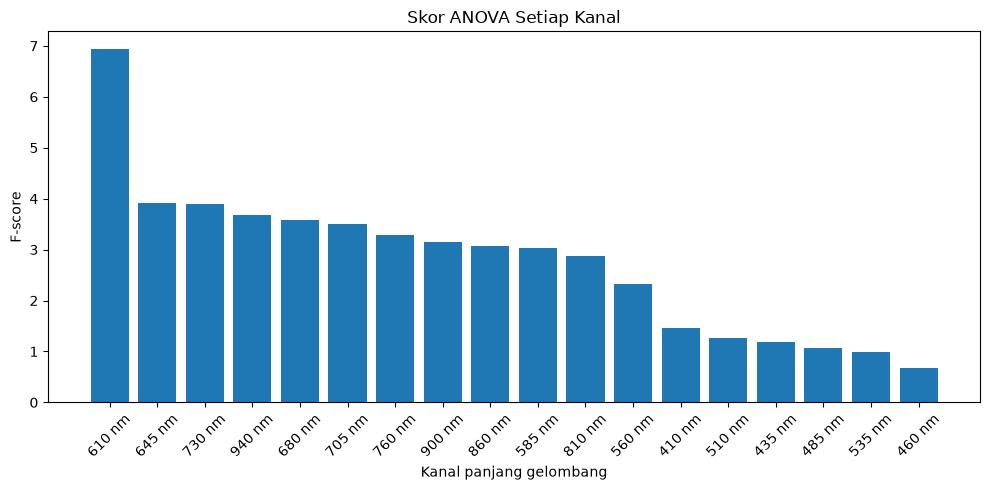

In [17]:
# ============================================================
# PERINGKAT KANAL BERDASARKAN ANOVA
# ============================================================

# Selector ini dipakai untuk interpretasi.
# Fit hanya dilakukan pada data latih agar tidak memakai informasi data uji.
selector_for_interpretation = SelectKBest(
    score_func=f_classif,
    k="all",
)

selector_for_interpretation.fit(X_train, y_train)

channel_scores = pd.DataFrame({
    "Kanal": wavelength_columns,
    "F-score": selector_for_interpretation.scores_,
    "p-value": selector_for_interpretation.pvalues_,
}).sort_values("F-score", ascending=False)

display(channel_scores)

top_4_channels = channel_scores.head(4)["Kanal"].tolist()
print("Empat kanal dengan F-score tertinggi pada data latih:")
print(top_4_channels)

plt.figure(figsize=(10, 5))
plt.bar(
    channel_scores["Kanal"],
    channel_scores["F-score"],
)
plt.xlabel("Kanal panjang gelombang")
plt.ylabel("F-score")
plt.title("Skor ANOVA Setiap Kanal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Catatan tentang Kanal Teratas

Daftar kanal teratas menunjukkan kanal yang paling berbeda antar kelas pada dataset kopi. Ini berguna untuk belajar membaca data spektral.

Namun, jangan langsung menyalin kanal ini untuk BuahSafe. Kerusakan internal jambu kristal memiliki mekanisme biologis berbeda dari tingkat sangrai kopi. Dataset primer jambu harus dianalisis ulang untuk menentukan kanal yang paling relevan.

# 15. Interpretasi Model dengan Permutation Importance

Model tidak cukup hanya menghasilkan prediksi. Kita juga perlu memahami fitur mana yang paling mempengaruhi prediksi.

Permutation importance bekerja dengan cara mengacak satu fitur, lalu melihat seberapa besar performa model turun. Jika performa turun besar, berarti fitur itu penting bagi model. Jika performa hampir tidak berubah, fitur itu mungkin kurang penting.

Metode ini bersifat model-agnostic, artinya dapat digunakan pada berbagai model. Namun, hasilnya menjelaskan perilaku model pada dataset tertentu, bukan membuktikan hubungan kimia-biologis secara langsung.

Model yang diinterpretasikan: SVM


,Kanal,Permutation importance,Simpangan baku
1,435 nm,0.2244,0.0285
17,940 nm,0.2148,0.0400
16,900 nm,0.2068,0.0412
14,810 nm,0.2013,0.0474
5,535 nm,0.1931,0.0355
15,860 nm,0.1912,0.0462
10,680 nm,0.1905,0.0377
13,760 nm,0.1888,0.0321
3,485 nm,0.1858,0.0362
2,460 nm,0.1790,0.0408


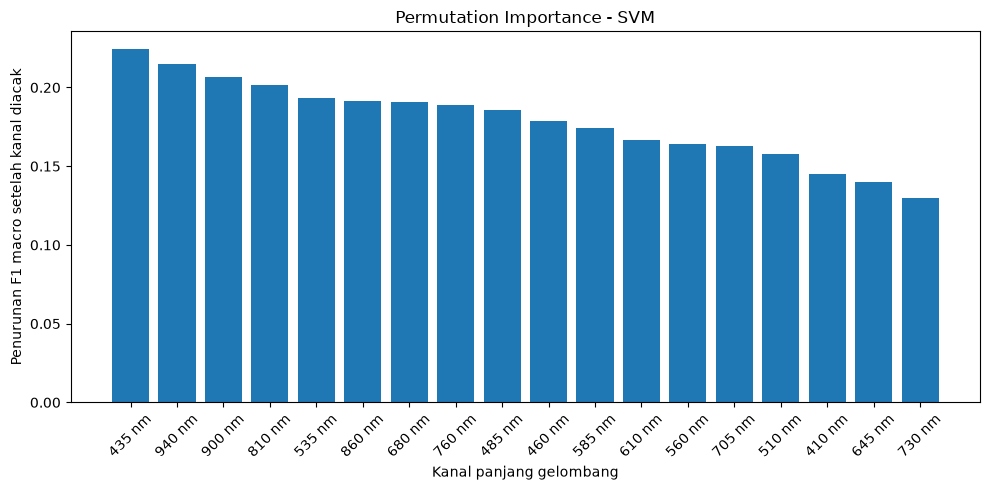

In [18]:
# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================

# Memilih model terbaik untuk interpretasi.
# Jika tuning dijalankan, gunakan hasil tuning terbaik.
if tuned_models:
    best_model_name = max(
        tuning_results,
        key=lambda result: result["Test F1 Macro"],
    )["Model"]

    best_classifier = tuned_models[best_model_name]

else:
    best_model_name = classification_results_df.iloc[0]["Model"]
    best_classifier = fitted_classification_models[best_model_name]

print("Model yang diinterpretasikan:", best_model_name)

# Mengukur pentingnya fitur pada data uji.
permutation_result = permutation_importance(
    estimator=best_classifier,
    X=X_test,
    y=y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    "Kanal": wavelength_columns,
    "Permutation importance": permutation_result.importances_mean,
    "Simpangan baku": permutation_result.importances_std,
}).sort_values(
    "Permutation importance",
    ascending=False,
)

display(permutation_df)

plt.figure(figsize=(10, 5))
plt.bar(
    permutation_df["Kanal"],
    permutation_df["Permutation importance"],
)
plt.xlabel("Kanal panjang gelombang")
plt.ylabel("Penurunan F1 macro setelah kanal diacak")
plt.title(f"Permutation Importance - {best_model_name}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cara Membaca Permutation Importance

Kanal dengan nilai importance tertinggi adalah kanal yang paling mempengaruhi performa model. Jika kanal itu diacak, model kehilangan informasi penting.

Dalam BuahSafe nanti, analisis ini bisa membantu menjelaskan mengapa model mengambil keputusan tertentu. Misalnya, jika kanal yang sensitif terhadap air atau struktur jaringan menjadi penting, hasil itu dapat dikaitkan dengan dasar biologis kerusakan internal. Namun, pengaitan tersebut harus didukung literatur dan data primer.

# 16. PCA: Melihat Struktur Data dalam Dua Dimensi

PCA atau Principal Component Analysis digunakan untuk mereduksi banyak fitur menjadi beberapa komponen. Pada dataset ini, 18 kanal direduksi menjadi dua komponen agar dapat divisualisasikan.

PCA bukan model klasifikasi utama. PCA hanya membantu melihat apakah kelas-kelas tampak memiliki pola pemisahan. Jika kelas terlihat saling tumpang tindih, model mungkin lebih sulit mengklasifikasikan. Jika kelas tampak terpisah, ada peluang model dapat belajar pola dengan lebih baik.

PCA berbeda dari feature selection. Feature selection memilih kanal asli. PCA membuat fitur baru dari kombinasi kanal.

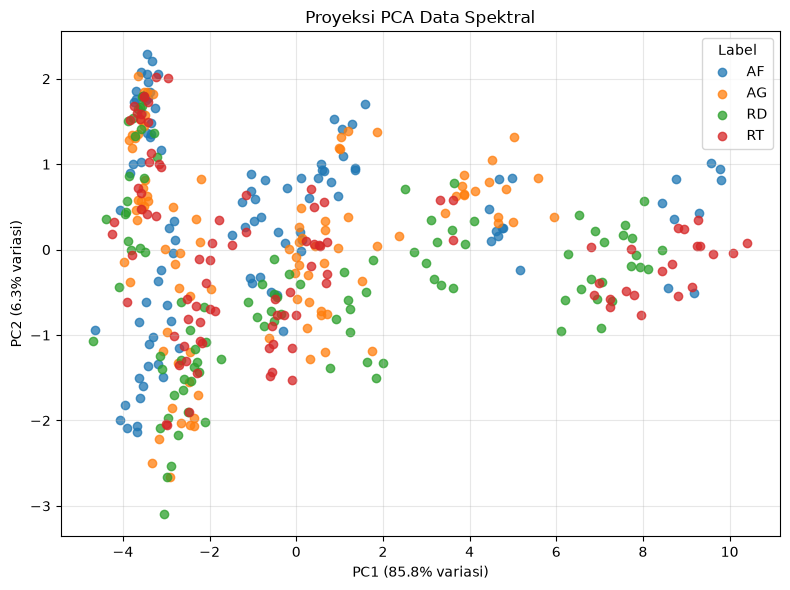

In [19]:
# ============================================================
# PCA DUA KOMPONEN
# ============================================================

pca_pipeline = Pipeline([
    # PCA sensitif terhadap skala, maka fitur distandarkan terlebih dahulu.
    ("scaler", StandardScaler()),

    # Data direduksi menjadi dua komponen agar bisa diplot.
    ("pca", PCA(n_components=2)),
])

X_pca = pca_pipeline.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Label": y_class.to_numpy(),
})

explained_variance = (
    pca_pipeline
    .named_steps["pca"]
    .explained_variance_ratio_
)

plt.figure(figsize=(8, 6))

for label, group in pca_df.groupby("Label"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=str(label),
        alpha=0.75,
    )

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variasi)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variasi)")
plt.title("Proyeksi PCA Data Spektral")
plt.legend(title="Label")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cara Membaca PCA

Setiap titik adalah satu sampel. Jika titik dari kelas yang sama berkumpul, berarti ada struktur pola. Jika titik antar kelas saling tumpang tindih, klasifikasi lebih sulit.

Namun, PCA hanya menampilkan dua komponen. Informasi penting mungkin masih berada pada komponen lain. Karena itu, PCA dipakai sebagai alat eksplorasi, bukan keputusan akhir.

# 17. Eksperimen Regresi terhadap Agtron Value

Bagian ini bertujuan memperluas pemahaman supervised learning. Klasifikasi memprediksi kelas, sedangkan regresi memprediksi angka.

Pada dataset kopi, `Agtron value` adalah target numerik. Model regresi mencoba memprediksi nilai tersebut dari 18 kanal spektral.

Model yang dibandingkan:

- Dummy Regressor sebagai baseline;
- Ridge Regression sebagai model linear;
- Support Vector Regression sebagai model non-linear berbasis SVM;
- Random Forest Regressor sebagai model tree ensemble.

Metrik regresi:

- **MAE**: rata-rata kesalahan absolut;
- **RMSE**: mirip MAE tetapi lebih menghukum error besar;
- **R²**: proporsi variasi target yang dapat dijelaskan model.

Dalam BuahSafe saat ini, klasifikasi lebih penting karena keputusan bisnisnya adalah normal atau rusak. Namun, regresi berguna jika suatu saat sistem ingin memprediksi skor mutu, indeks risiko, atau tingkat kerusakan.

In [20]:
# ============================================================
# MODEL REGRESI
# ============================================================

regression_results_df = None
fitted_regression_models = {}

if RUN_REGRESSION:

    # Untuk regresi, targetnya numerik sehingga tidak menggunakan stratify.
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X,
        y_reg,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    regression_models = {
        "Dummy Baseline": DummyRegressor(strategy="mean"),

        "Ridge Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),

        "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(
                C=10,
                epsilon=0.1,
                kernel="rbf",
            )),
        ]),

        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    regression_cv = KFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    regression_results = []

    for model_name, model in regression_models.items():

        cv_scores = cross_validate(
            estimator=model,
            X=X,
            y=y_reg,
            cv=regression_cv,
            scoring={
                "mae": "neg_mean_absolute_error",
                "r2": "r2",
            },
            n_jobs=-1,
        )

        fitted_model = clone(model)
        fitted_model.fit(X_reg_train, y_reg_train)

        predictions = fitted_model.predict(X_reg_test)
        fitted_regression_models[model_name] = fitted_model

        regression_results.append({
            "Model": model_name,
            "CV MAE": -cv_scores["test_mae"].mean(),
            "CV R2": cv_scores["test_r2"].mean(),
            "Test MAE": mean_absolute_error(
                y_reg_test,
                predictions,
            ),
            "Test RMSE": np.sqrt(
                mean_squared_error(
                    y_reg_test,
                    predictions,
                )
            ),
            "Test R2": r2_score(
                y_reg_test,
                predictions,
            ),
        })

    regression_results_df = (
        pd.DataFrame(regression_results)
        .sort_values("Test R2", ascending=False)
        .reset_index(drop=True)
    )

    display(
        regression_results_df.style.format({
            column: "{:.4f}"
            for column in regression_results_df.columns
            if column != "Model"
        })
    )

else:
    print("Eksperimen regresi dilewati.")

,Model,CV MAE,CV R2,Test MAE,Test RMSE,Test R2
0,Random Forest Regressor,2.3471,0.9921,2.2546,3.1718,0.9928
1,Ridge Regression,2.6209,0.9915,2.6898,3.4679,0.9914
2,SVR,2.7552,0.9902,3.0034,3.8507,0.9894
3,Dummy Baseline,31.2535,-0.0102,32.1613,37.9367,-0.0266


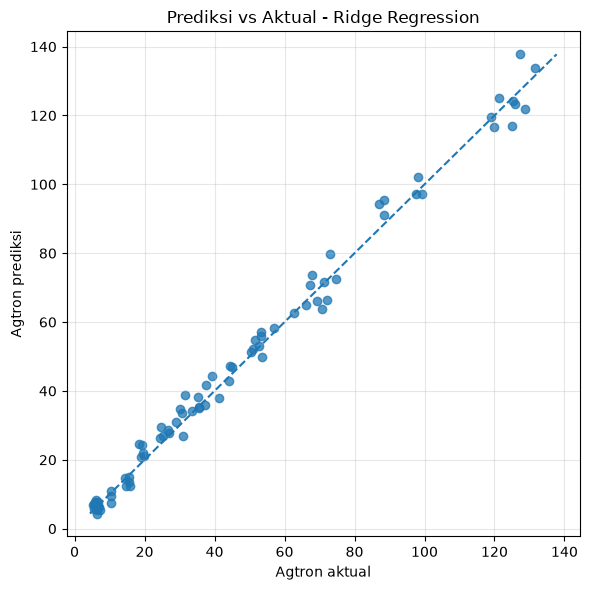

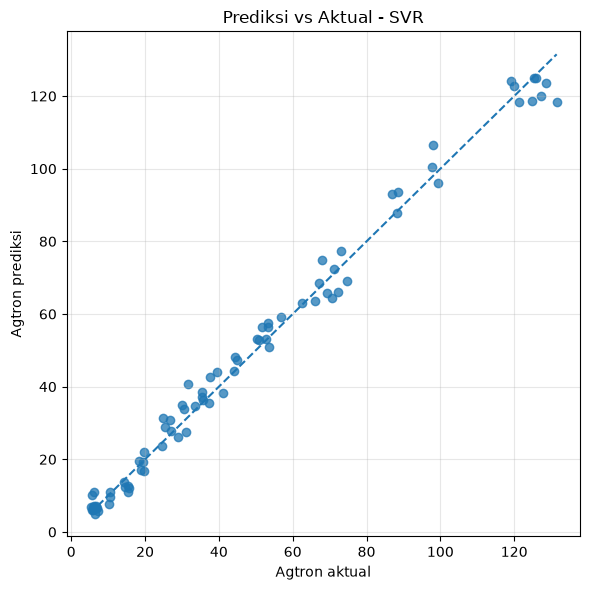

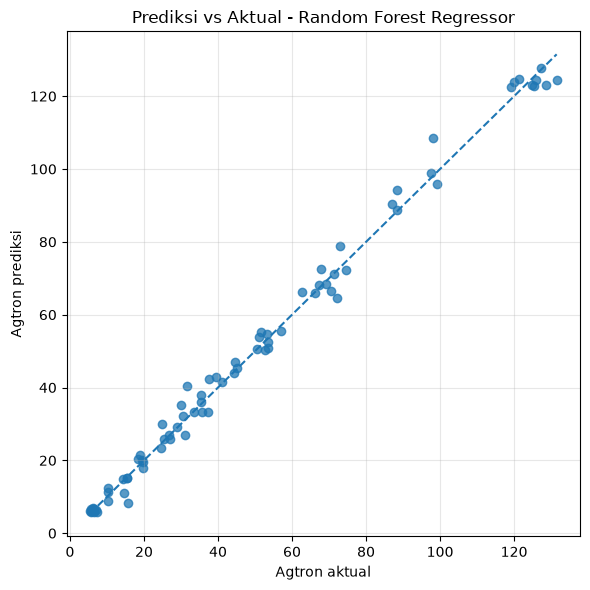

In [21]:
# ============================================================
# VISUALISASI PREDIKSI REGRESI
# ============================================================

if RUN_REGRESSION:

    for model_name in [
        "Ridge Regression",
        "SVR",
        "Random Forest Regressor",
    ]:
        model = fitted_regression_models[model_name]
        predictions = model.predict(X_reg_test)

        plt.figure(figsize=(6, 6))
        plt.scatter(
            y_reg_test,
            predictions,
            alpha=0.75,
        )

        minimum_value = min(
            y_reg_test.min(),
            predictions.min(),
        )
        maximum_value = max(
            y_reg_test.max(),
            predictions.max(),
        )

        # Garis diagonal menunjukkan prediksi sempurna.
        plt.plot(
            [minimum_value, maximum_value],
            [minimum_value, maximum_value],
            linestyle="--",
        )

        plt.xlabel("Agtron aktual")
        plt.ylabel("Agtron prediksi")
        plt.title(f"Prediksi vs Aktual - {model_name}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## Cara Membaca Regresi

Jika titik-titik berada dekat garis diagonal, prediksi mendekati nilai aktual. Jika titik menyebar jauh, model banyak salah.

MAE dan RMSE menjelaskan besar kesalahan. R² menjelaskan seberapa besar variasi target dapat dijelaskan model. Nilai R² tinggi tampak bagus, tetapi tetap harus dibaca hati-hati. Jika ada pengukuran berulang dari sampel yang sama, evaluasi bisa terlalu optimistis jika split tidak berbasis ID sampel.

# 18. Menyimpan Model dan Hasil Eksperimen

Notebook menyimpan beberapa artefak:

- model klasifikasi terbaik;
- model regresi terbaik;
- hasil evaluasi klasifikasi;
- hasil tuning;
- hasil feature selection;
- permutation importance;
- metadata eksperimen;
- file ZIP berisi seluruh output.

Penyimpanan ini berguna untuk dokumentasi dan pelaporan. Namun, model yang disimpan tetap hanya model kopi. Jangan gunakan model ini untuk memprediksi jambu kristal.

In [22]:
# ============================================================
# MENYIMPAN ARTEFAK EKSPERIMEN
# ============================================================

# Menentukan folder output.
if Path("/content").exists():
    output_directory = Path("/content/buahsafe_learning_outputs")
else:
    output_directory = Path.cwd() / "buahsafe_learning_outputs"

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

# Menyimpan model klasifikasi terbaik.
joblib.dump(
    best_classifier,
    output_directory / "best_coffee_classifier.joblib",
)

# Metadata membantu reproduksibilitas eksperimen.
metadata = {
    "dataset_url": DATA_URL,
    "dataset_sha256": sha256,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "wavelength_columns": wavelength_columns,
    "top_4_channels_learning_only": top_4_channels,
    "best_classifier_name": best_model_name,
}

with open(
    output_directory / "experiment_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

classification_results_df.to_csv(
    output_directory / "classification_results.csv",
    index=False,
)

if RUN_HYPERPARAMETER_TUNING:
    tuning_results_df.to_csv(
        output_directory / "classification_tuning_results.csv",
        index=False,
    )

if RUN_FEATURE_SELECTION_BENCHMARK:
    feature_selection_results_df.to_csv(
        output_directory / "feature_selection_results.csv",
        index=False,
    )

permutation_df.to_csv(
    output_directory / "permutation_importance.csv",
    index=False,
)

if RUN_REGRESSION and regression_results_df is not None:
    best_regression_name = regression_results_df.iloc[0]["Model"]
    best_regressor = fitted_regression_models[best_regression_name]

    joblib.dump(
        best_regressor,
        output_directory / "best_coffee_regressor.joblib",
    )

    regression_results_df.to_csv(
        output_directory / "regression_results.csv",
        index=False,
    )

# Mengemas seluruh output menjadi ZIP.
archive_path = output_directory.parent / "buahsafe_learning_outputs.zip"

with zipfile.ZipFile(
    archive_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in output_directory.rglob("*"):
        if file_path.is_file():
            archive.write(
                file_path,
                arcname=file_path.relative_to(output_directory.parent),
            )

print("Folder output:", output_directory)
print("Arsip ZIP   :", archive_path)

print("\nDaftar file output:")
for file_path in sorted(output_directory.iterdir()):
    print("-", file_path.name)

Folder output: f:\My Files\Projects\buahsafe\buahsafe_learning_outputs
Arsip ZIP   : f:\My Files\Projects\buahsafe\buahsafe_learning_outputs.zip

Daftar file output:
- best_coffee_classifier.joblib
- best_coffee_regressor.joblib
- classification_results.csv
- classification_tuning_results.csv
- experiment_metadata.json
- feature_selection_results.csv
- permutation_importance.csv
- regression_results.csv


# 19. Kesimpulan Pembelajaran dari Dataset Sekunder

Notebook ini menunjukkan bagaimana data spektral dari sensor AS7265x dapat diolah menjadi input machine learning. Prosesnya dimulai dari audit dataset, eksplorasi pola spektral, pemisahan data latih dan uji, pelatihan beberapa model, evaluasi performa, tuning, feature selection, interpretasi fitur, hingga penyimpanan hasil.

Dari sisi teknis, notebook ini memperlihatkan bahwa data spektral bukan sekadar angka mentah. Setiap kanal merepresentasikan respons sampel pada panjang gelombang tertentu. Model machine learning kemudian mencari kombinasi pola antar kanal untuk membedakan kelas atau memprediksi nilai numerik.

Dari sisi business logic BuahSafe, pipeline ini adalah simulasi awal bagaimana alat sortasi berbasis sensor dapat bekerja. Sensor menghasilkan data, model membaca pola, lalu sistem memberi keputusan yang dapat membantu quality control. Nilai bisnisnya bukan pada model sebagai kode, tetapi pada kemampuannya mengurangi risiko buah bermasalah lolos sortasi, mempercepat inspeksi, dan membuat proses pengendalian mutu lebih terdokumentasi.

Namun, kesimpulan dari dataset kopi tidak boleh langsung digeneralisasi ke jambu kristal. Dataset ini hanya membuktikan bahwa pipeline dapat dijalankan dan dipahami. Pembuktian kemampuan BuahSafe tetap harus menggunakan dataset primer jambu kristal yang dikumpulkan dengan prosedur sensor, chamber, label destruktif, dan validasi yang benar.

# 20. Adaptasi ke Dataset Primer BuahSafe

Ketika dataset jambu kristal sudah tersedia, jangan menggabungkannya dengan dataset kopi. Gunakan dataset primer sebagai eksperimen baru.

## Struktur Data Primer yang Disarankan

| Kolom | Fungsi |
|---|---|
| `fruit_id` | Identitas unik setiap buah |
| `scan_id` | Identitas setiap pemindaian |
| `label` | `normal` atau `rusak` berdasarkan verifikasi destruktif |
| `410 nm` sampai `940 nm` | Intensitas 18 kanal AS7265x |
| `tanggal_scan` | Waktu pengukuran |
| `posisi_scan` | Orientasi atau titik scan |
| `ulangan` | Nomor ulangan scan |
| `catatan_internal` | Larva, rongga, busuk, sehat, atau kondisi lain |

## Perubahan Kode Utama

```python
wavelength_columns = [
    column for column in df_primary.columns
    if column.endswith("nm")
]

X = df_primary[wavelength_columns]
y = df_primary["label"]
groups = df_primary["fruit_id"]
```

## Validasi yang Lebih Tepat

Jika satu buah dipindai beberapa kali, gunakan `GroupKFold` atau `StratifiedGroupKFold`. Tujuannya adalah memastikan semua scan dari satu buah masuk ke kelompok yang sama. Ini mencegah model mengenali buah yang sama pada data latih dan data uji.

## Fokus Evaluasi BuahSafe

Pada dataset primer, metrik yang perlu diperhatikan bukan hanya accuracy. Jika tujuan bisnis utama adalah mencegah buah rusak lolos, maka recall pada kelas `rusak` sangat penting. Jika recall rendah, berarti banyak buah rusak yang gagal terdeteksi. Jika precision rendah, berarti banyak buah normal yang ditandai rusak.

Dalam penerapan quality control, trade-off ini perlu dibahas bersama mitra. Sistem yang terlalu ketat dapat membuang buah normal. Sistem yang terlalu longgar dapat meloloskan buah rusak. Model terbaik adalah model yang sesuai dengan risiko operasional mitra.

# 21. Pertanyaan Refleksi untuk Tim BuahSafe

Gunakan notebook ini untuk menjawab pertanyaan berikut:

1. Apakah model utama mengalahkan Dummy Classifier?
2. Model mana yang paling stabil antara cross-validation dan test set?
3. Apakah model dengan hasil tertinggi juga paling masuk akal untuk dijelaskan?
4. Kelas mana yang paling sering tertukar?
5. Apakah tuning benar-benar meningkatkan performa?
6. Apakah 4 kanal cukup mendekati performa 18 kanal?
7. Kanal apa yang paling penting menurut ANOVA?
8. Kanal apa yang paling penting menurut permutation importance?
9. Apakah ANOVA dan permutation importance memberi hasil serupa?
10. Mengapa model kopi tidak boleh digunakan langsung untuk jambu kristal?
11. Mengapa dataset primer harus memiliki `fruit_id`?
12. Untuk BuahSafe, mana yang lebih berbahaya: buah rusak lolos atau buah normal tertolak?
13. Metrik apa yang harus diprioritaskan untuk mitra?
14. Data tambahan apa yang perlu dicatat saat pengambilan data primer?
15. Apa yang harus dilakukan jika performa model primer rendah?

Pertanyaan-pertanyaan ini membantu tim memahami bahwa machine learning bukan hanya soal menjalankan algoritma. Machine learning dalam penelitian dan bisnis harus selalu dikaitkan dengan data, risiko, keputusan operasional, dan validasi yang jujur.

# 22. Kesimpulan Akhir

Notebook ini adalah jembatan antara konsep proposal dan implementasi penelitian. Proposal menjelaskan mengapa BuahSafe penting, sedangkan notebook ini menunjukkan bagaimana data sensor dapat diproses menjadi model yang dapat dievaluasi.

Secara teknis, notebook ini melatih tim untuk mengelola data spektral AS7265x, menjalankan model klasifikasi dan regresi, membaca metrik, melakukan tuning, memilih fitur, dan menginterpretasikan kanal penting. Secara bisnis, notebook ini melatih cara berpikir bahwa model harus mendukung keputusan quality control, bukan sekadar menghasilkan angka akurasi.

Tahap berikutnya adalah mengumpulkan dataset primer jambu kristal dengan prosedur yang konsisten. Setelah data primer tersedia, pipeline ini dapat digunakan ulang dengan penyesuaian pada target, validasi berbasis `fruit_id`, dan metrik yang lebih sesuai dengan risiko operasional BuahSafe.